In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
##Ethanol Bottle_012.csv, Storage Bag.csv, Salsa Container_010.csv, nylon string.csv, string_006.csv, Zip Tie_014.csv, 
##Fishing Line_013.csv, Water bottle_014.csv, Heat Sealable Film_009.csv, Gloves.csv, Glove 2.csv
def load_IR_csv(name):
    d = pd.read_csv(f"NK_AJ_AW/{name}.csv", skiprows=1)
    d.columns = ["wn", "T"]
    return d
Eth_bottle_IR= load_IR_csv("string_006")
print(Eth_bottle_IR.head)


<bound method NDFrame.head of           wn      T
0     4000.0  97.93
1     3999.0  97.92
2     3998.0  97.92
3     3997.0  97.92
4     3996.0  97.92
...      ...    ...
3596   404.0  86.48
3597   403.0  86.56
3598   402.0  86.60
3599   401.0  86.28
3600   400.0  85.59

[3601 rows x 2 columns]>


In [25]:
##$Ethanol bottle.csv, $String.csv
def load_DSC(name):
    d = pd.read_csv(f"N_A_A/{name}.csv", skiprows=1,encoding="latin-1")
    d.columns = ["T", "Q"]
    return d
Eth_bottle_DSC = load_DSC("$Ethanol bottle")
print(Eth_bottle_DSC.head)

<bound method NDFrame.head of               T           Q
0     29.976358  -51.040394
1     30.274673 -126.273308
2     30.565733 -216.632401
3     30.864202 -290.613464
4     31.199203 -286.209167
..          ...         ...
806  298.576324  -62.470295
807  298.909271  -62.696388
808  299.242188  -62.951763
809  299.574982  -63.257980
810  299.907806  -63.573112

[811 rows x 2 columns]>


In [26]:
FTIR = {
    "Ethanol Bottle_012": "Ethanol bottle", "Storage Bag": "Storage bag",
    "Salsa Container_010": "Salsa container", "nylon string": '"Nylon" string',
    "string_006": "String", "Zip Tie_014": "Zip tie", "Fishing Line_013": "Fishing line",
    "Water bottle_014": "Water bottle", "Heat Sealable Film_009": "Heat-sealable film",
    "Gloves": "Glove 1", "Glove 2": "Glove 2",
}

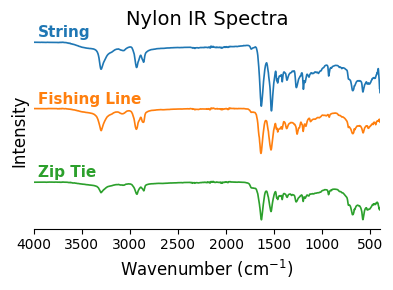

In [54]:
##Ziptie,Sting,Fishing line all had nylon according to IR##
##STACKED SPECTRA##
spectra = [
    ("string_006", "String"),
    ("Fishing Line_013", "Fishing Line"),
    ("Zip Tie_014", "Zip Tie"),
]
OFFSET = 18
fig, ax = plt.subplots(figsize=(4,3))
 
n = len(spectra)
for i, (name, label) in enumerate(spectra):
    d = load_IR_csv(name)
    shift = (n - 1 - i) * OFFSET 
    line, = ax.plot(d["wn"], d["T"] + shift, lw=1.2)
    ax.text(3950, d["T"].iloc[:50].mean() + shift + 1.2, label, color=line.get_color(), fontsize=11, fontweight="bold")


 
ax.set_xlim(4000, 400)                     
ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
ax.set_ylabel("Intensity", fontsize=12)
ax.set_title("Nylon IR Spectra", fontsize=14)
ax.set_yticks([])                 
ax.spines[["top", "right", "left"]].set_visible(False)
 
plt.tight_layout()
plt.savefig("stacked_ir_spectra_str_fish_zip.png", dpi=300)
plt.show()



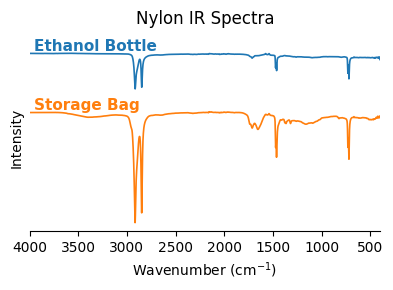

In [58]:
##Looking at the FTIR SPECTRA with reported same material##
spectra = [
    ("Ethanol Bottle_012", "Ethanol Bottle"),
    ("Storage Bag", "Storage Bag"),
]
OFFSET = 30
fig, ax = plt.subplots(figsize=(4,3))
 
n = len(spectra)
for i, (name, label) in enumerate(spectra):
    d = load_IR_csv(name)
    shift = (n - 1 - i) * OFFSET 
    line, = ax.plot(d["wn"], d["T"] + shift, lw=1.2)
    ax.text(3950, d["T"].iloc[:50].mean() + shift + 1.2, label, color=line.get_color(), fontsize=11, fontweight="bold")


 
ax.set_xlim(4000, 400)                     
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.set_title("Nylon IR Spectra",pad =15)
ax.set_yticks([])                 
ax.spines[["top", "right", "left"]].set_visible(False)
 
plt.tight_layout()
plt.savefig("stacked_ir_spectra_eth_stor.png")
plt.show()


230.166748


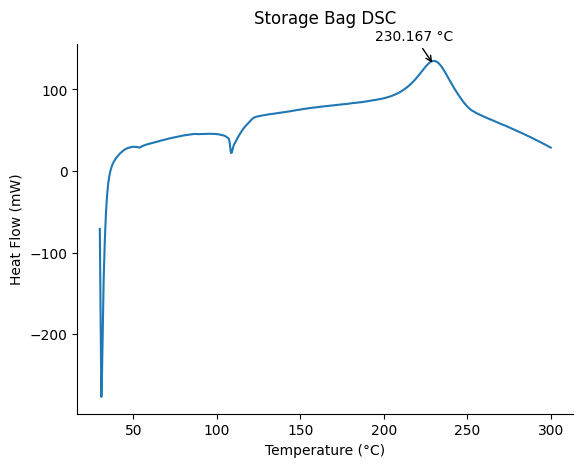

In [116]:
df = load_DSC("$Storage Bag")
plt.plot(df["T"], df["Q"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Heat Flow (mW)")
plt.title("Storage Bag DSC",pad =15)
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
t_max = df.loc[df['Q'].idxmax(), 'T']
print(t_max)
ax.annotate("230.167 °C", xy=(230, 130), xytext=(195, 160), arrowprops=dict(arrowstyle="->"))


plt.show()


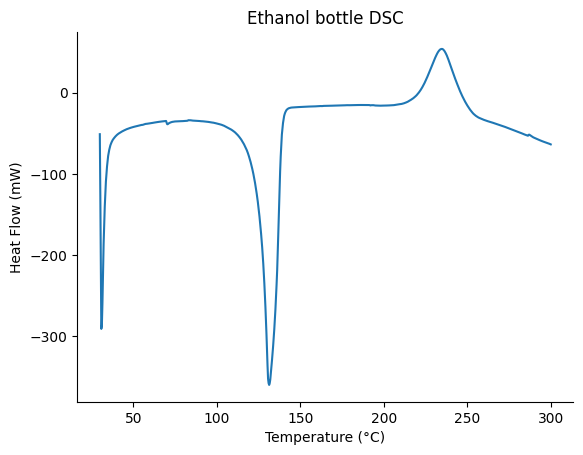

In [88]:
## STORAGE GRAPH  MATERIAL: PE ###

df = load_DSC("$Ethanol bottle")
plt.plot(df["T"], df["Q"])   # your column names here
plt.xlabel("Temperature (°C)")
plt.ylabel("Heat Flow (mW)")
plt.title("Ethanol bottle DSC")
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
plt.show()


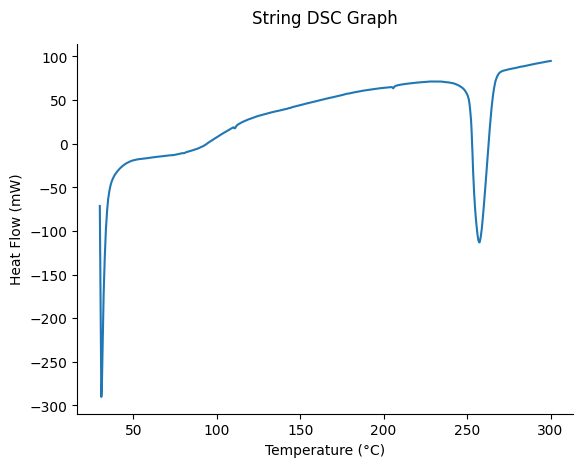

In [91]:
## STRING GRAPH  MATERIAL: NYLON ###

df = load_DSC("$String")
plt.plot(df["T"], df["Q"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Heat Flow (mW)")
plt.title("String DSC Graph",pad =15)
ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
plt.show()

In [ ]:
## DSC: NYLON SAMPLES STACKED (String, Fishing line, Zip tie) ##
# Each sample: (file name, label, where to look for the melting dip: low °C, high °C)
samples = [
    ("$String",       "String",       230, 280),
    ("$Fishing line", "Fishing line", 200, 225),
    ("$Ziptie",       "Zip tie",      230, 280),
]
colors = ["#2a78d6", "#eb6834", "#1baf7a"]   # blue, orange, green (colorblind-safe)
OFFSET = 150                                # space between the curves

fig, ax = plt.subplots(figsize=(6, 4.5))

n = len(samples)
for i, (name, label, low, high) in enumerate(samples):
    d = load_DSC(name)
    d = d[d["T"] > 40]                          # cut off the start-up spike below 40 °C
    shift = (n - 1 - i) * OFFSET                # first sample goes on top
    y = d["Q"] - d["Q"].iloc[0] + shift         # start each curve at 0, then move it up
    ax.plot(d["T"], y, color=colors[i], lw=1.5)

    # Melting point = lowest point (biggest dip) inside the search window
    in_window = (d["T"] > low) & (d["T"] < high)
    dip = y[in_window].idxmin()
    tm = d["T"][dip]
    ax.plot(tm, y[dip], "o", color=colors[i], ms=5)
    ax.text(tm, y[dip] - 12, f"{tm:.0f} °C", ha="center", va="top", fontsize=9)

    # Sample name just above the left end of its curve
    ax.text(45, shift + 25, label, fontsize=11, fontweight="bold")

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Heat Flow (mW), endo down", fontsize=12)
ax.set_title("DSC of Nylon Samples", fontsize=14, pad=15)
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)
ax.margins(y=0.12)                              # extra room so the bottom label isn't cut off

plt.tight_layout()
plt.savefig("stacked_dsc_nylon.png", dpi=300)
plt.show()

In [ ]:
## DSC: PE SAMPLES STACKED (Storage bag, Ethanol bottle) ##
# Each sample: (file name, label, where to look for the melting dip: low °C, high °C)
samples = [
    ("$Storage bag",    "Storage bag",    90, 150),
    ("$Ethanol bottle", "Ethanol bottle", 90, 150),
]
colors = ["#2a78d6", "#eb6834"]              # blue, orange (colorblind-safe)
OFFSET = 150                                # space between the curves

fig, ax = plt.subplots(figsize=(6, 4.5))

n = len(samples)
for i, (name, label, low, high) in enumerate(samples):
    d = load_DSC(name)
    d = d[d["T"] > 40]                          # cut off the start-up spike below 40 °C
    shift = (n - 1 - i) * OFFSET                # first sample goes on top
    y = d["Q"] - d["Q"].iloc[0] + shift         # start each curve at 0, then move it up
    ax.plot(d["T"], y, color=colors[i], lw=1.5)

    # Melting point = lowest point (biggest dip) inside the search window
    in_window = (d["T"] > low) & (d["T"] < high)
    dip = y[in_window].idxmin()
    tm = d["T"][dip]
    ax.plot(tm, y[dip], "o", color=colors[i], ms=5)
    ax.text(tm, y[dip] - 12, f"{tm:.0f} °C", ha="center", va="top", fontsize=9)

    # Sample name just above the left end of its curve
    ax.text(45, shift + 25, label, fontsize=11, fontweight="bold")

ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Heat Flow (mW), endo down", fontsize=12)
ax.set_title("DSC of Polyethylene (PE) Samples", fontsize=14, pad=15)
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)
ax.margins(y=0.12)                              # extra room so the bottom label isn't cut off

plt.tight_layout()
plt.savefig("stacked_dsc_PE.png", dpi=300)
plt.show()